### Data Drift Baseline

Analyze the temporal distribution of the training dataset to understand how samples are spread across the day. This allows us to establish a baseline value for detecting time-based data drift.

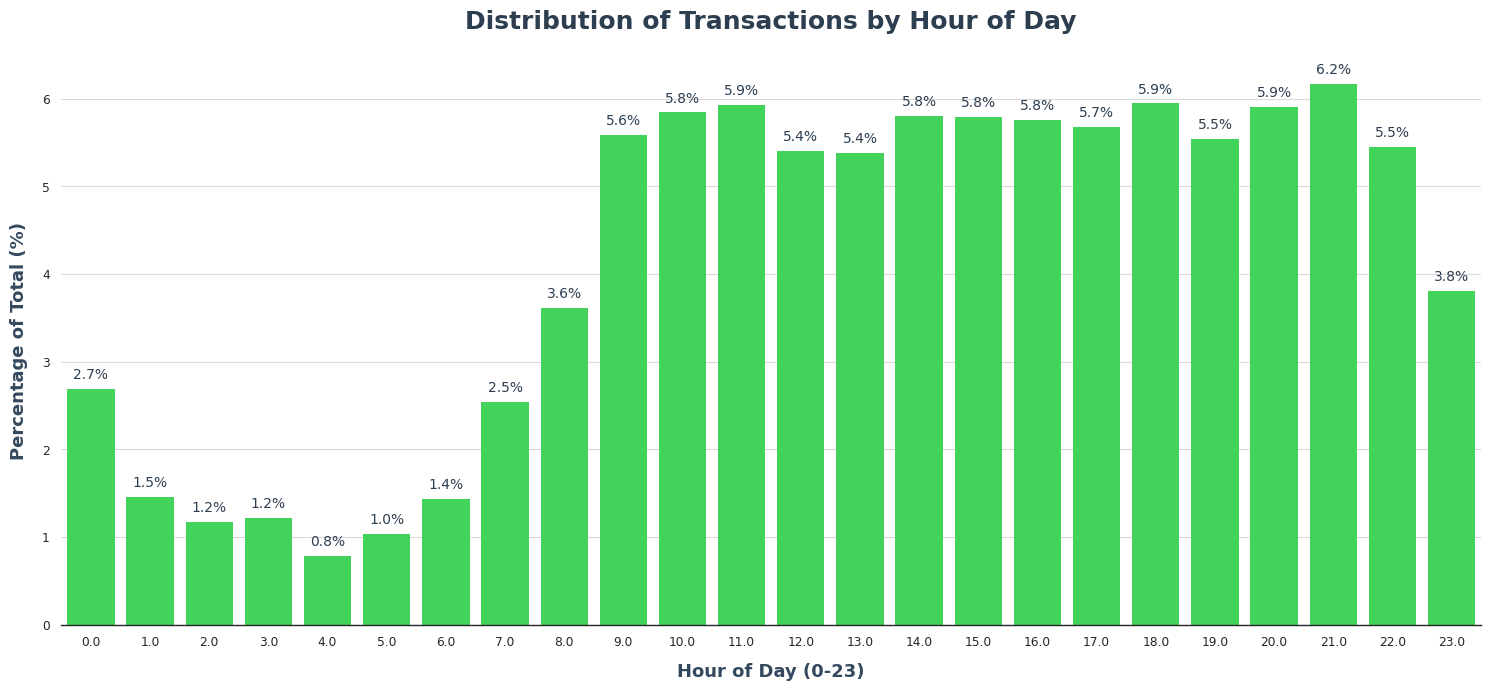

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("files/train_dataset_balanced.csv")

df['hour_of_day'] = (df['Time'] // 3600) % 24

hourly_percentages = df['hour_of_day'].value_counts(normalize=True).sort_index() * 100
hourly_df = hourly_percentages.reset_index()
hourly_df.columns = ['hour_of_day', 'percentage']

sns.set_theme(style="white", context="paper") 

plt.figure(figsize=(15, 7))

ax = sns.barplot(
    data=hourly_df, 
    x='hour_of_day', 
    y='percentage', 
    color="#2BEB4B",
    edgecolor="none"     
)

plt.title('Distribution of Transactions by Hour of Day', 
          fontsize=18, fontweight='bold', color='#2C3E50', pad=20)
plt.xlabel('Hour of Day (0-23)', fontsize=13, fontweight='bold', color='#34495E', labelpad=10)
plt.ylabel('Percentage of Total (%)', fontsize=13, fontweight='bold', color='#34495E', labelpad=10)

plt.grid(axis='y', linestyle='-', alpha=0.15, color='black')
ax.set_axisbelow(True) 

sns.despine(left=True, bottom=False)

for p in ax.patches:
    height = p.get_height()
    if height > 0: 
        ax.annotate(f'{height:.1f}%', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    fontsize=10, color='#2C3E50', fontweight='500',
                    xytext=(0, 5), 
                    textcoords='offset points')

plt.tight_layout()